# Crop a GRS L2A image and export the subset

This notebook extracts an area of interest (AOI) from a GRS **L2A** product and writes it as a new,
smaller L2A product that can be reopened with `grstbx.L2grs` like any GRS image.

Workflow:

1. **Settings**: input product, output directory and format, default AOI;
2. **Preview** the image at a coarse resolution (pyramid level) and **draw the AOI** on an interactive map;
3. **Crop** the full-resolution product to the AOI: all variables, flags and the ancillary data;
4. **Export** to NetCDF or Zarr with the GRS packing, plus an optional GeoTIFF of $R_{rs}$;
5. **Check** the exported product, then optionally apply the same AOI to a series of images.

The crop and export functions are part of grstbx (module `grstbx.subset`):
`grstbx.open_l2a`, `grstbx.aoi_from_box`, `grstbx.crop_l2a`, `grstbx.export_l2a`,
`grstbx.export_rrs_geotiff`, `grstbx.subset_path` and `grstbx.crop_and_export`.
The maps use `grstbx.plot_rgb` (true-colour composite with the AOI outline) and `grstbx.utm_projection`.

**Performance**

- The preview and the drawing use a coarse pyramid level and only the three true-colour bands,
  so a whole tile is displayed in a few seconds.
- The crop is lazy: `rio.clip_box` slices the dask arrays, so only the chunks intersecting the AOI
  are read from disk, whatever the size of the tile.
- The pixels outside a non-rectangular AOI are masked on the small subset only (`rasterio`
  rasterization). The integer `flags` and `mask` keep their dtype, unlike with `rio.clip`, which
  converts them to float.

**Input:** a GRS L2A product, either a Zarr store (`*.zarr`, single resolution or multiscale pyramid
with an `ancillary` group) or a folder `<name>/` holding `<name>.nc` and `<name>_anc.nc`.

## 1. Libraries

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
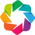

grs:    3.0.1dev
grstbx: 2.2.0


In [1]:
import os
import glob

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import panel as pn

import grs
import grstbx
from grstbx import visual, plot_rgb, utm_projection

pn.extension()
opj = os.path.join

print(f'grs:    {grs.__version__}')
print(f'grstbx: {grstbx.__version__}')

## 2. Settings

All the parameters are gathered in the next cell:

| parameter | description |
|---|---|
| `FILE` | input L2A product (`.zarr` store or NetCDF folder) |
| `SITE` | name of the AOI, appended to the output file names |
| `ODIR` | output directory; each subset is written in `ODIR/SITE/` |
| `FMT` | `'netcdf'` (`<name>.nc` + `<name>_anc.nc` in a folder `<name>/`) or `'zarr'` (`<name>.zarr`, with pyramids) |
| `PREVIEW_LEVEL` | pyramid level used for the preview and the drawing (e.g. 2 = 4x coarser); ignored for single-resolution products |
| `MASK_OUTSIDE` | for a non-rectangular AOI, mask the pixels outside the polygon (otherwise its bounding box is kept as is) |
| `AOI_FILE` | optional vector file (GeoJSON, shapefile, GeoPackage...) defining the AOI |
| `CENTER_LONLAT`, `BOX_SIZE_M` | default AOI: rectangle of `BOX_SIZE_M` (width, height in m) centred on (lon, lat) |

The AOI actually used is, by order of priority: the **polygon drawn** on the map of section 3, the
polygons of `AOI_FILE`, the default box.

In [3]:
FILE = ('/data/satellite/Sentinel-2/test/'
        'S2A_MSIL2AGRS_20170412T110621_N0500_R137_T30TWT_20231111T110836_V3.0.1dev/'
        'S2A_MSIL2AGRS_20170412T110621_N0500_R137_T30TWT_20231111T110836_V3.0.1dev.zarr')

SITE = 'loire_estuary'
ODIR = '/data/tmp/grstbx_subset'
FMT = 'netcdf'          # 'netcdf' or 'zarr'
PREVIEW_LEVEL = 2
MASK_OUTSIDE = True

AOI_FILE = None         # e.g. '/path/to/aoi.geojson'
CENTER_LONLAT = (-2.5, 47.12)
BOX_SIZE_M = (35000, 35000)

## 3. Preview and AOI drawing

`grstbx.open_l2a` opens the product lazily (nothing is loaded yet) together with its ancillary data
(CAMS fields and gaseous transmittance on a coarse ~10 km grid), which is exported with the subset.

In [4]:
levels = grstbx.zarr_levels(FILE) if grstbx.driver.is_zarr(FILE) else []
preview_level = min(PREVIEW_LEVEL, len(levels) - 1) if levels else 0

l2a_prod, ancillary = grstbx.open_l2a(FILE)
preview, _ = grstbx.open_l2a(FILE, level=preview_level)
crs = l2a_prod.rio.crs
proj = utm_projection(crs)

print(f'pyramid levels: {levels or "single resolution"}')
for name, ds in [('full resolution', l2a_prod), (f'preview (level {preview_level})', preview)]:
    print(f'{name:22s}: {ds.sizes["x"]} x {ds.sizes["y"]} pixels, {abs(ds.rio.resolution()[0]):.0f} m')
print(f'CRS: {crs}, date: {l2a_prod.time.dt.date.values}')

pyramid levels: ['0', '1', '2', '3', '4']
full resolution       : 5490 x 5490 pixels, 20 m
preview (level 2)     : 1373 x 1373 pixels, 80 m
CRS: EPSG:32630, date: 2017-04-12


Default AOI (from `AOI_FILE` or the box around `CENTER_LONLAT`), drawn in red on the preview:

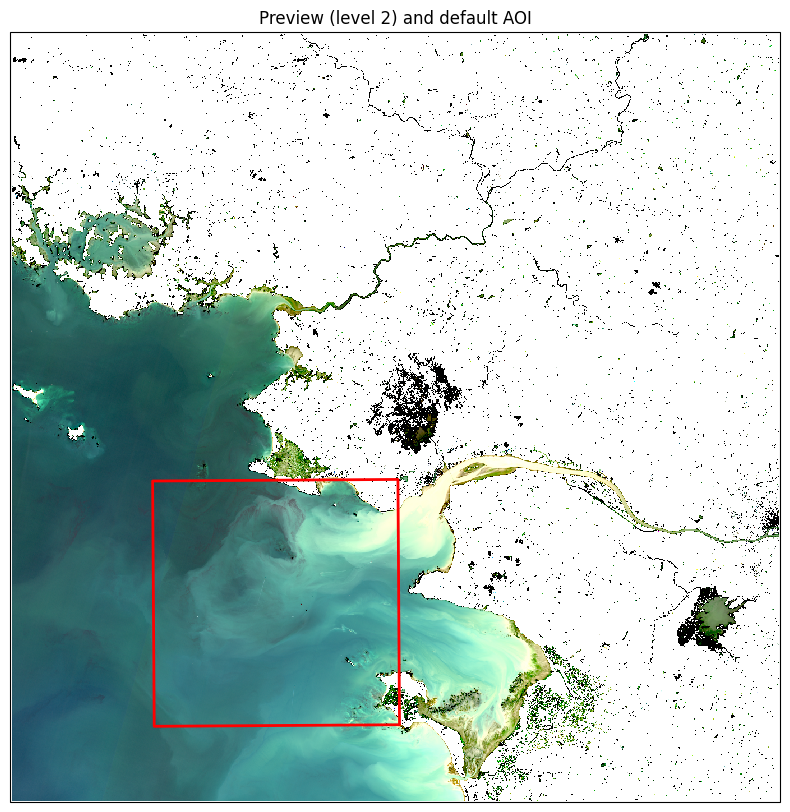

In [5]:
if AOI_FILE:
    default_aoi = gpd.read_file(AOI_FILE)
else:
    default_aoi = grstbx.aoi_from_box(*CENTER_LONLAT, width=BOX_SIZE_M[0], height=BOX_SIZE_M[1])

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': proj})
plot_rgb(preview, ax, aoi=default_aoi)
ax.set_title(f'Preview (level {preview_level}) and default AOI');

To use another AOI, draw it on the map below with the **Polygon Draw** tool of the toolbar:
double-click to start the polygon, click to add vertices, double-click to close it. Only the **last**
polygon drawn is used. Then run the next cells. Without a drawing, the default AOI is kept.

In [8]:
viewer = visual.ViewSpectral(preview.Rrs, bands=[490, 560, 665], reproject=True,
                             minmaxvalues=(0, 0.04), minmax=(0, 0.1))
viewer.visu()

Column
    [0] WidgetBox
        [0] Markdown(str)
        [1] Column
            [0] Row
                [0] Markdown(str)
                [1] RadioButtonGroup(options=[0, 1, 2], value=2)
            [1] Row
                [0] Row
                    [0] Markdown(str)
                    [1] DatePicker(enabled_dates=[datetime.date(2017, ...], start=datetime.date(2017, ..., value=datetime.date(2017, ...)
                [1] Row
                    [0] Markdown(str)
                    [1] Select(options=['CartoDark', ...], value='CartoDark')
            [2] Row
                [0] Row
                    [0] Markdown(str)
                    [1] EditableRangeSlider(end=0.1, name='Range Slider', step=0.0001, value=(0, 0.04), width=300)
                [1] Row
                    [0] Markdown(str)
                    [1] FloatSlider(name='Opacity', step=0.05, value=0.95)
                [2] Row
                    [0] Markdown(str)
                    [1] Select(options=['CET_D13', 'bky', ...], value='CET_D13')
        [2] HoloViews(Layout)

In [9]:
if len(viewer.aoi_stream.data.get('xs', [])) > 0:
    aoi, aoi_source = viewer.get_geom(viewer.aoi_stream, crs=4326), 'drawn polygon'
else:
    aoi, aoi_source = default_aoi.to_crs(4326), AOI_FILE or 'default box'

print(f'AOI: {aoi_source}, bounds (lon/lat): {np.round(aoi.total_bounds, 4)}')
aoi

AOI: default box, bounds (lon/lat): [-2.7313 46.9624 -2.2687 47.2772]


,geometry
0,"POLYGON ((-2.26871 47.27718, -2.73129 47.27718..."


## 4. Crop

`grstbx.crop_l2a` cuts the full-resolution product to the bounding box of the AOI. With
`mask_outside=True`, the pixels outside the polygon(s) are then flagged as missing, following the GRS
conventions:

- float variables (`Rrs`, `BRDFg`, angles...) set to NaN;
- bit 0 (`nodata`) of `flags` raised;
- `mask` set to 1 (invalid pixel).

The ancillary data are cropped to the same bounding box enlarged by one coarse cell, so that they
can still be interpolated over the whole subset. The result is lazy: `.load()` reads the chunks
intersecting the AOI only.

In [10]:
subset, subset_anc = grstbx.crop_l2a(l2a_prod, aoi, ancillary, mask_outside=MASK_OUTSIDE)
subset = subset.load()

print(f'subset: {subset.sizes["x"]} x {subset.sizes["y"]} pixels, '
      f'{subset.nbytes / 1e6:.0f} MB in memory, '
      f'{float(((subset.flags & 1) == 0).mean()) * 100:.0f}% of the pixels inside the AOI')
subset

subset: 1761 x 1762 pixels, 462 MB in memory, 99% of the pixels inside the AOI


<xarray.Dataset> Size: 462MB
Dimensions:             (x: 1761, y: 1762, wl: 11)
Coordinates:
  * x                   (x) float64 14kB 5.203e+05 5.204e+05 ... 5.555e+05
  * y                   (y) float64 14kB 5.236e+06 5.236e+06 ... 5.201e+06
  * wl                  (wl) int64 88B 443 490 560 665 705 ... 842 865 1610 2190
    central_wavelength  (wl) float32 44B 442.7 492.7 ... 1.614e+03 2.202e+03
    time                datetime64[ns] 8B 2017-04-12T11:06:21
    spatial_ref         int64 8B 0
Data variables:
    BRDFg               (y, x) float64 25MB nan nan nan nan ... nan nan nan nan
    Rrs                 (wl, y, x) float64 273MB nan nan nan nan ... nan nan nan
    aot550              (y, x) float64 25MB nan nan nan nan ... nan nan nan nan
    dem                 (y, x) float64 25MB nan nan nan nan ... nan nan nan nan
    flags               (y, x) uint32 12MB 537 537 537 537 ... 521 521 521 521
    mask                (y, x) uint8 3MB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    raa                 (y, x) float64 25MB nan nan nan nan ... nan nan nan nan
    sza                 (y, x) float64 25MB nan nan nan nan ... nan nan nan nan
    vza                 (y, x) float64 25MB nan nan nan nan ... nan nan nan nan
    wind                (y, x) float64 25MB nan nan nan nan ... nan nan nan nan
Attributes: (12/80)
    CLOUD_COVERAGE_ASSESSMENT:           0.0
    DATATAKE_1_DATATAKE_SENSING_START:   2017-04-12T11:06:21.026Z
    DATATAKE_1_DATATAKE_TYPE:            INS-NOBS
    DATATAKE_1_ID:                       GS2A_20170412T110621_009429_N05.00
    DATATAKE_1_SENSING_ORBIT_DIRECTION:  DESCENDING
    DATATAKE_1_SENSING_ORBIT_NUMBER:     137
    ...                                  ...
    tile:                                30TWT
    version:                             3.0.1dev
    vis_swir_index_threshold:            0.0
    water_vapor_transmittance_file:      /home/harmel/anaconda3/envs/py12/lib...
    wl_to_process:                       [443, 490, 560, 665, 705, 740, 783, ...
    pyramid_level:                       0

True colour and GRS water mask of the subset:

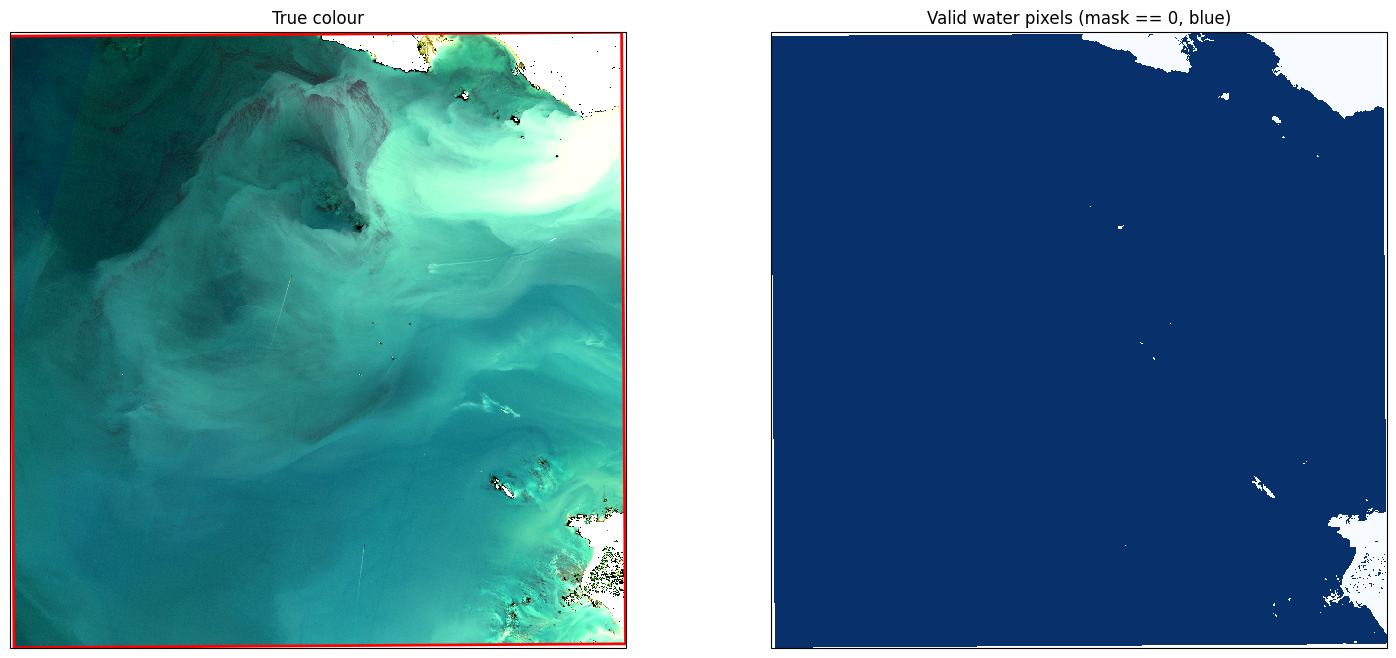

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'projection': proj})
plot_rgb(subset, axs[0], aoi=aoi)
axs[0].set_title('True colour')
(subset['mask'] == 0).where((subset.flags & 1) == 0).plot.imshow(
    ax=axs[1], cmap='Blues', vmin=0, vmax=1, add_colorbar=False)
axs[1].set_title('Valid water pixels (mask == 0, blue)');

## 5. Export

`grstbx.export_l2a` writes the subset with the exporters of GRS (`grs.output.L2aProduct`, the `grs`
package is needed), so it has the same layout and packing as the products of the processor:

- `Rrs`, `BRDFg`, `aot550`, angles, `dem`: `int16` with `scale_factor` / `add_offset`
  (e.g. 1e-5 sr$^{-1}$ for `Rrs`); `flags` and `mask` unchanged; other variables (e.g. `wind`) as float32;
- **NetCDF** (`.nc`): `<name>/<name>.nc` (main) and `<name>/<name>_anc.nc` (ancillary), zlib compression;
- **Zarr** (`.zarr`): `<name>.zarr` with the full resolution in group `0`, the overviews (pyramid) when
  the subset is larger than 512 pixels, and the group `ancillary`.

`grstbx.subset_path` builds the output path from the input name and `SITE`. The returned `out` is the
path to give to `grstbx.L2grs` (NetCDF product folder or Zarr store).

In [12]:
out = grstbx.export_l2a(subset, grstbx.subset_path(FILE, ODIR, SITE, FMT), ancillary=subset_anc)

size = sum(os.path.getsize(opj(root, f)) for root, _, files in os.walk(out) for f in files)
print(f'{out}  ({size / 1e6:.2f} MB)')
print(sorted(os.listdir(out)))

/data/tmp/grstbx_subset/loire_estuary/S2A_MSIL2AGRS_20170412T110621_N0500_R137_T30TWT_20231111T110836_V3.0.1dev_loire_estuary  (34.11 MB)
['S2A_MSIL2AGRS_20170412T110621_N0500_R137_T30TWT_20231111T110836_V3.0.1dev_loire_estuary.nc', 'S2A_MSIL2AGRS_20170412T110621_N0500_R137_T30TWT_20231111T110836_V3.0.1dev_loire_estuary_anc.nc']


### Optional: GeoTIFF of $R_{rs}$

A multi-band GeoTIFF (one band per wavelength, float32, NaN outside the AOI / on missing pixels) for
GIS software. Set `water_only=True` to keep only the valid water pixels (`mask == 0`).

In [10]:
tif = grstbx.export_rrs_geotiff(subset, opj(ODIR, SITE, os.path.basename(out).removesuffix('.zarr') + '_Rrs.tif'))
print(tif, f'{os.path.getsize(tif) / 1e6:.2f} MB')

/data/tmp/grstbx_subset/loire_estuary/S2A_MSIL2AGRS_20170412T110621_N0500_R137_T30TWT_20231111T110836_V3.0.1dev_loire_estuary_Rrs.tif 11.06 MB


## 6. Check the exported product

Reopen the subset with `grstbx.L2grs`, as for any GRS product, and compare it with the data in memory.
The differences come from the `int16` packing only (at most half the `scale_factor`, i.e. 5e-6 sr$^{-1}$
for `Rrs`) and are zero when the input was itself a GRS product.

In [15]:
import xarray as xr
groups_dict=xr.open_groups(out, engine="zarr")
group_list = list(groups_dict.keys())
print(group_list)

GroupNotFoundError: No group found in store '/data/tmp/grstbx_subset/loire_estuary/S2A_MSIL2AGRS_20170412T110621_N0500_R137_T30TWT_20231111T110836_V3.0.1dev_loire_estuary' at path ''

/home/harmel/Dropbox/Dropbox/work/git/satellite_app/grstbx/grstbx/driver.py:152: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 1000. This could degrade performance. Instead, consider rechunking after loading.
  raster = xr.open_dataset(main_file,
/home/harmel/Dropbox/Dropbox/work/git/satellite_app/grstbx/grstbx/driver.py:152: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 1000. This could degrade performance. Instead, consider rechunking after loading.
  raster = xr.open_dataset(main_file,
/home/harmel/Dropbox/Dropbox/work/git/satellite_app/grstbx/grstbx/driver.py:259: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_optio

max |dRrs| : 0.0
flags equal: True uint32
flag statistics of the subset:
flag_nodata                        0.014
flag_cloud_p06                     0.000
flag_cloud_p08                     0.000
flag_water_swir_visible_index      0.961
flag_water_red_visible_index       0.960
flag_thin_cirrus                   0.000
flag_opac_cirrus                   0.000
flag_high_swir                     0.003
flag_surfwater_land                0.000
flag_surfwater_water               1.000
flag_surfwater_cloud_and_shadow    0.000
flag_OCM_Thick_Cloud               0.000
flag_OCM_Thin_Cloud                0.000
flag_OCM_Cloud_Shadow              0.000
flag_neg_rrs                       0.003


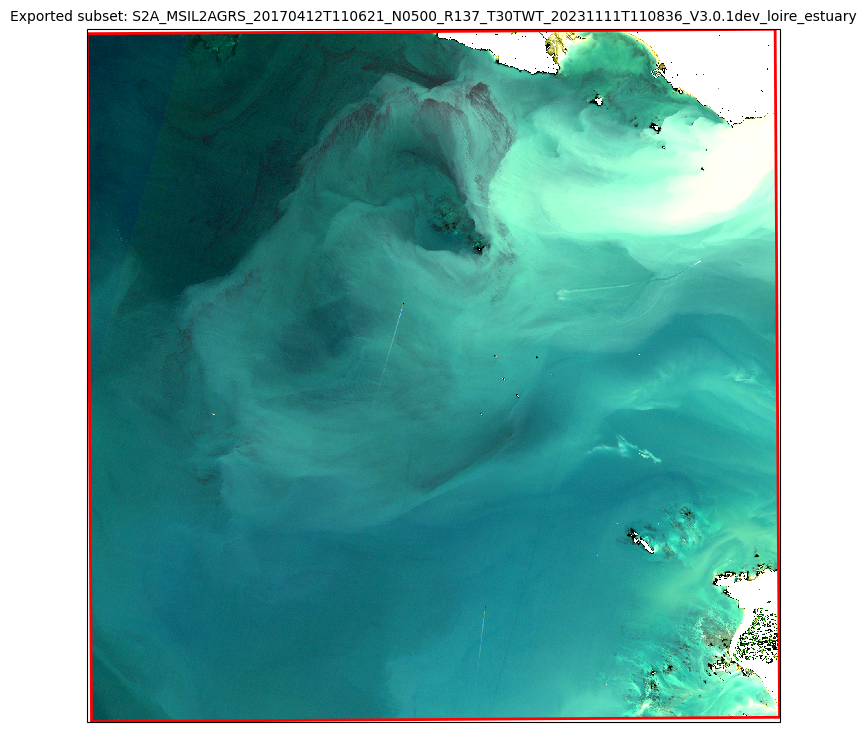

In [13]:
dc = grstbx.L2grs([out])
dc.get_l2a_datacube(nodata_thresh=1.)
reloaded = dc.datacube.isel(time=0)

print('max |dRrs| :', float(abs(reloaded.Rrs - subset.Rrs).max()))
print('flags equal:', bool((reloaded.flags.values == subset.flags.values).all()), reloaded.flags.dtype)
print('flag statistics of the subset:')
print(dc.datacube[[v for v in dc.datacube.data_vars if v.startswith('flag_')]]
      .isel(time=0).to_pandas().round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': proj})
plot_rgb(reloaded, ax, aoi=aoi)
ax.set_title(f'Exported subset: {os.path.basename(out)}', fontsize=10);

## 7. Apply the AOI to a series of images

`grstbx.crop_and_export` opens, crops and exports a product in one call; existing outputs are skipped
(`overwrite=False`). Set `RUN_BATCH = True` to process every product matching `PATTERN` with the same AOI.

In [12]:
RUN_BATCH = False
PATTERN = '/data/satellite/Sentinel-2/test/*T30TWT*/*.zarr'

if RUN_BATCH:
    for file in sorted(glob.glob(PATTERN)):
        print(grstbx.crop_and_export(file, aoi, grstbx.subset_path(file, ODIR, SITE, FMT),
                                     mask_outside=MASK_OUTSIDE))